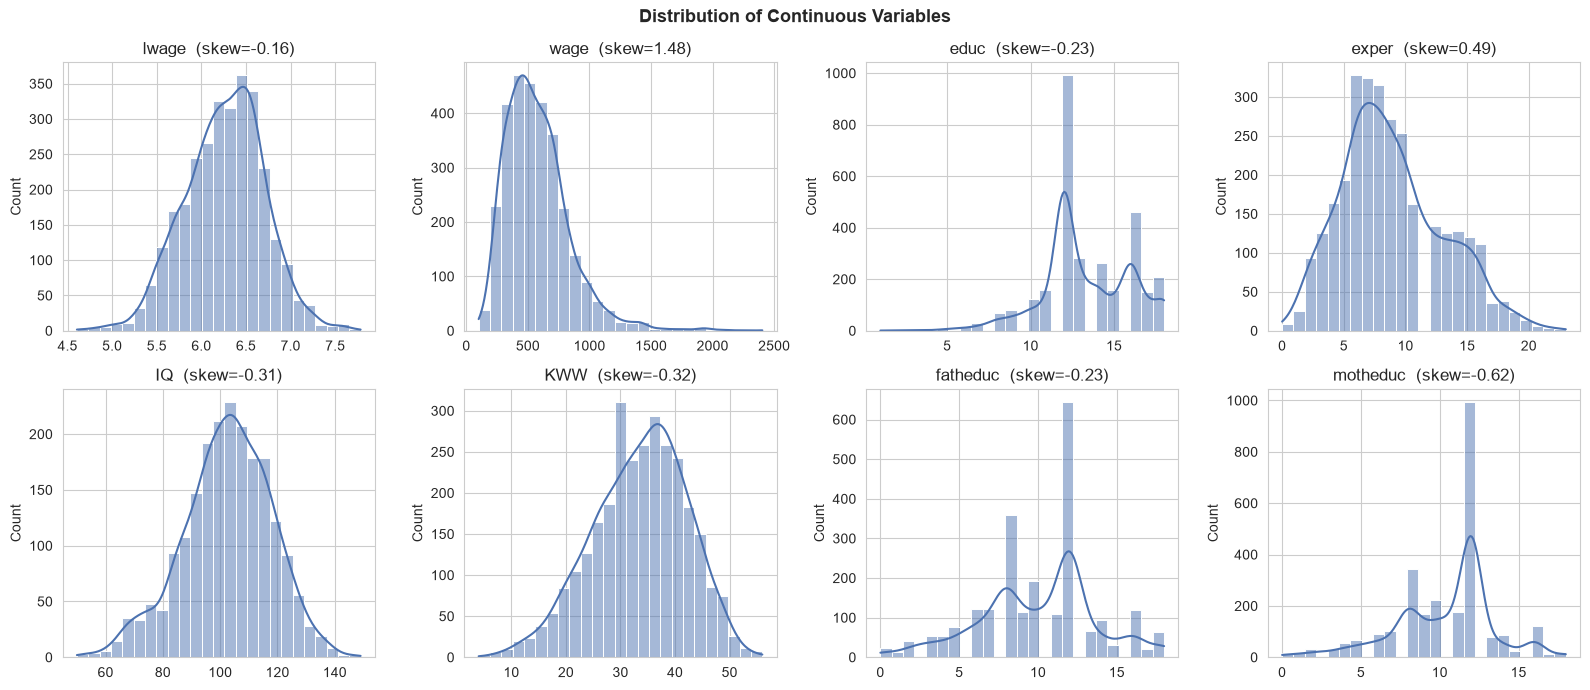

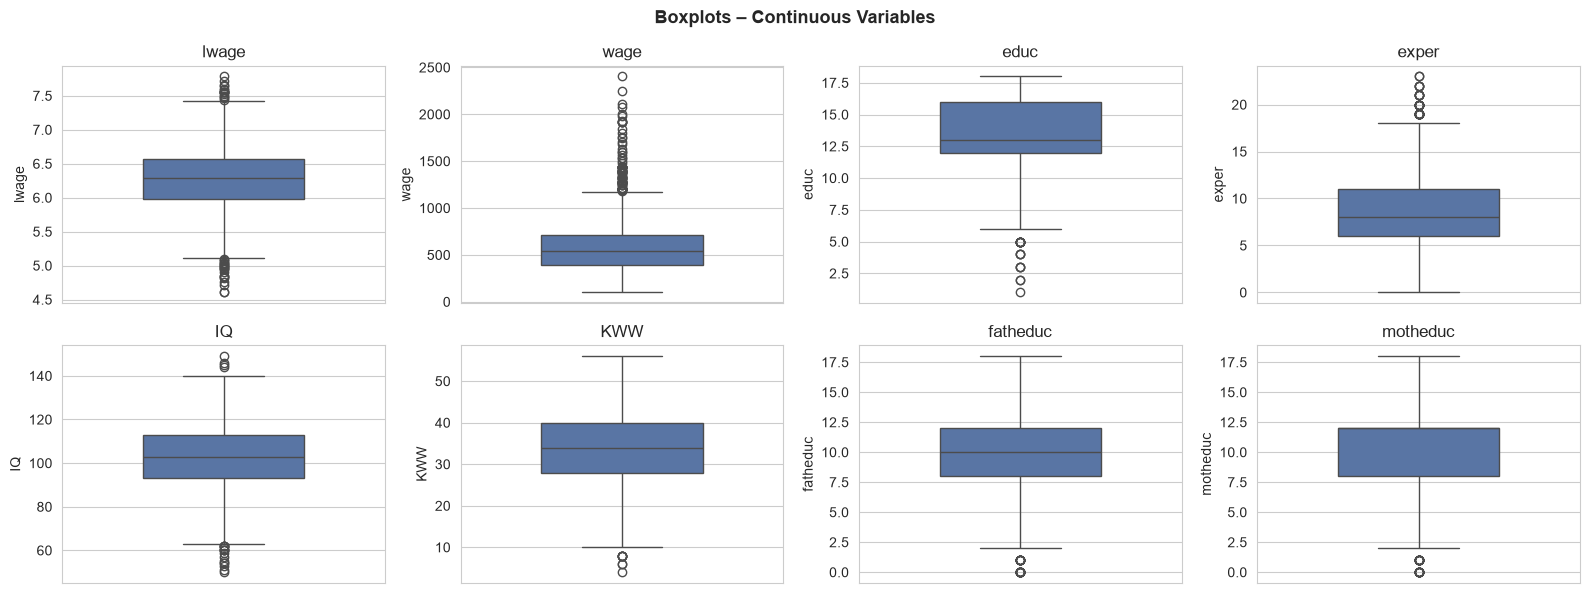

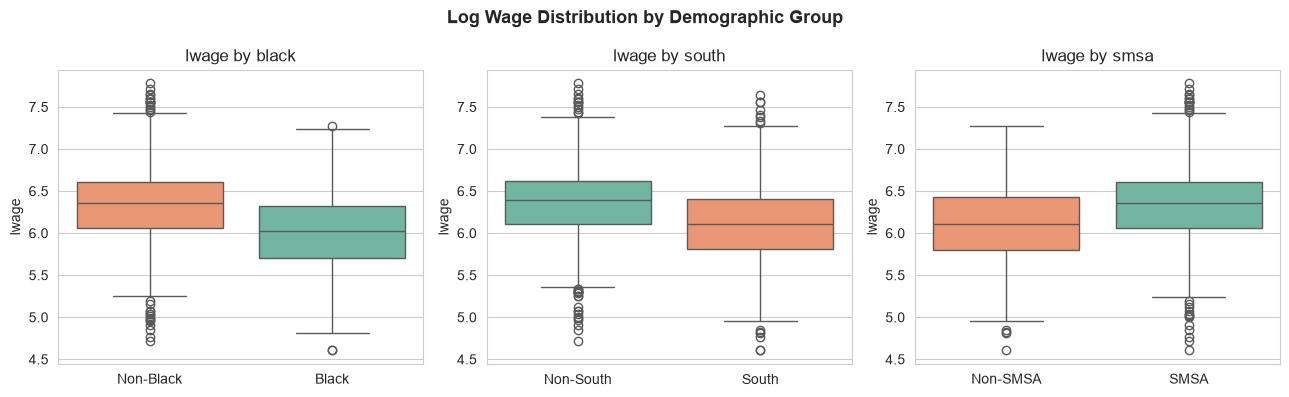

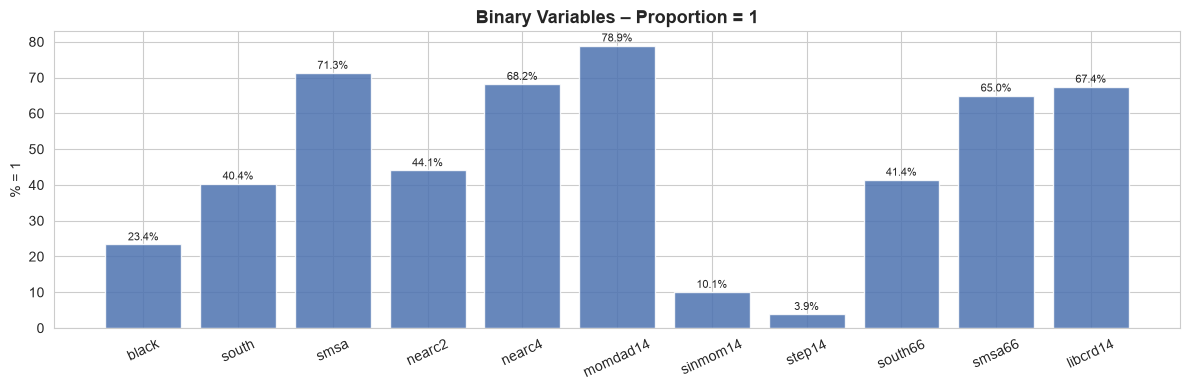

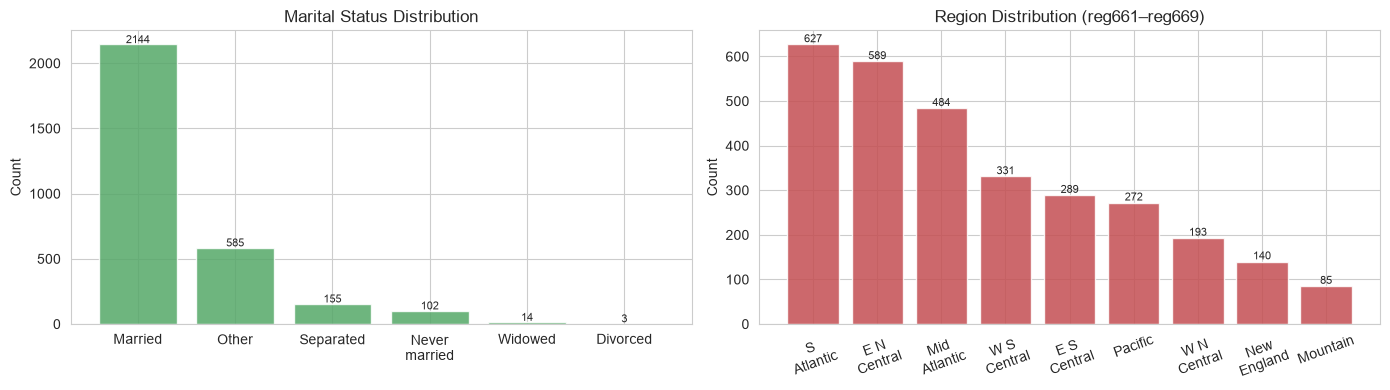

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
df = pd.read_csv("DATA/wage_eda.csv")

continuous = ["lwage", "wage", "educ", "exper", "IQ", "KWW", "fatheduc", "motheduc"]

# ── 1. Histogram + KDE – all continuous variables ─────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(continuous):
    sns.histplot(df[col].dropna(), kde=True, bins=25, ax=axes[i], color="#4C72B0")
    sk = df[col].skew()
    axes[i].set_title(f"{col}  (skew={sk:.2f})")
    axes[i].set_xlabel("")
fig.suptitle("Distribution of Continuous Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 2. Boxplots – continuous variables (outlier check) ────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(continuous):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="#4C72B0", width=0.5)
    axes[i].set_title(col)
fig.suptitle("Boxplots – Continuous Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3. lwage boxplot by demographic groups ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
groups = [("black",  {0:"Non-Black", 1:"Black"}),
          ("south",  {0:"Non-South", 1:"South"}),
          ("smsa",   {0:"Non-SMSA",  1:"SMSA"})]

for ax, (col, lmap) in zip(axes, groups):
    df_plot = df.copy()
    df_plot[col] = df_plot[col].map(lmap)          # convert 0/1 → label
    sns.boxplot(data=df_plot, x=col, y="lwage",
                hue=col, palette="Set2",            # assign hue = x
                order=list(lmap.values()),
                legend=False, ax=ax)
    ax.set_title(f"lwage by {col}")
    ax.set_xlabel("")

fig.suptitle("Log Wage Distribution by Demographic Group", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 4. Binary variables – bar chart (all 11 binary vars) ──────
binary = ["black","south","smsa","nearc2","nearc4",
          "momdad14","sinmom14","step14","south66","smsa66","libcrd14"]
pct_1 = df[binary].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(binary, pct_1, color="#4C72B0", edgecolor="white", alpha=0.85)
for bar, val in zip(bars, pct_1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("% = 1")
ax.set_title("Binary Variables – Proportion = 1", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# ── 5. Married & Region distribution ─────────────────────────
married_map = {1:"Married", 2:"Widowed", 3:"Divorced",
               4:"Separated", 5:"Never\nmarried", 6:"Other"}
reg_cols = ["reg661","reg662","reg663","reg664","reg665","reg666","reg667","reg668","reg669"]
reg_map  = {"reg661":"New\nEngland","reg662":"Mid\nAtlantic","reg663":"E N\nCentral",
            "reg664":"W N\nCentral","reg665":"S\nAtlantic","reg666":"E S\nCentral",
            "reg667":"W S\nCentral","reg668":"Mountain","reg669":"Pacific"}
df["region"] = df[reg_cols].idxmax(axis=1).map(reg_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Married
m_vc = df["married"].map(married_map).value_counts()
axes[0].bar(m_vc.index, m_vc.values, color="#55A868", edgecolor="white", alpha=0.85)
for i, (lbl, val) in enumerate(m_vc.items()):
    axes[0].text(i, val + 10, f"{val}", ha="center", fontsize=8)
axes[0].set_title("Marital Status Distribution")
axes[0].set_ylabel("Count")

# Region
r_vc = df["region"].value_counts()
axes[1].bar(r_vc.index, r_vc.values, color="#C44E52", edgecolor="white", alpha=0.85)
for i, (lbl, val) in enumerate(r_vc.items()):
    axes[1].text(i, val + 5, f"{val}", ha="center", fontsize=8)
axes[1].set_title("Region Distribution (reg661–reg669)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()